# Exploring Convolutional Layers Through Data and Experiments

**Dataset:** Fashion-MNIST
**Author:** Isaac Burgos

This notebook walks through: EDA, a non-convolutional baseline, a from-scratch
CNN design, a controlled experiment on kernel size, and an interpretation of
why (and when) convolution helps. See `README.md` for the written report
version of this same content (architecture diagrams, results tables).


In [1]:
import sys
sys.path.insert(0, "..")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, classification_report

from src.data import get_dataloaders, load_raw_datasets, CLASS_NAMES, FASHION_MNIST_MEAN, FASHION_MNIST_STD
from src.models import BaselineMLP, SimpleCNN, count_parameters
from src.train import train_model, evaluate

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cpu


## 1. Dataset Selection and Justification

**Dataset:** [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) (Zalando Research),
loaded through `torchvision.datasets.FashionMNIST`.

**Why this dataset is appropriate for studying convolutional layers:**

- **Image-based, 2D tensors:** 28x28 grayscale product photos (1 channel) — small enough to
  iterate quickly on a laptop CPU, but real photographic images (not synthetic shapes), so
  local structure (edges, textures, silhouettes) is meaningful and convolution has something
  genuine to exploit.
- **10 classes, balanced:** clothing categories (shirts, sneakers, bags, ...) with enough
  visual overlap between classes (e.g. *Shirt* vs *T-shirt/top* vs *Pullover*) that a model
  ignoring spatial structure (a plain dense network) is expected to struggle more than it
  does on plain MNIST digits — this is precisely why Fashion-MNIST was created: MNIST digits
  are "too easy" and no longer separate architectures well.
- **Fits in memory:** 70,000 images x 28x28x1 bytes is a few hundred MB at most — the whole
  dataset can be loaded and iterated without any streaming/sharding logic, keeping the focus
  on architecture rather than data engineering.
- **Translation / local-pattern structure:** the same sole shape can appear anywhere in a
  sneaker's bounding box, the same seam pattern can appear anywhere on a shirt — exactly the
  kind of "the same local feature can appear at different positions" assumption that
  convolution's weight sharing and translation equivariance are built to exploit. A dataset
  without local spatial structure (e.g. tabular data) would not exercise convolution's
  inductive bias at all, which is why an image dataset is required here.

**Constraints satisfied:** image-based (28x28x1 tensors), 10 classes (>= 2), ~30MB on disk —
comfortably fits in memory on a standard laptop.


In [2]:
train_raw, test_raw = load_raw_datasets()
print(f"Train samples: {len(train_raw)}")
print(f"Test samples:  {len(test_raw)}")

image, label = train_raw[0]
print(f"Image shape: {tuple(image.shape)}  (channels, height, width)")
print(f"Pixel value range: [{image.min().item():.3f}, {image.max().item():.3f}]")
print(f"Number of classes: {len(CLASS_NAMES)}")
print(f"Class names: {CLASS_NAMES}")


Train samples: 60000
Test samples:  10000
Image shape: (1, 28, 28)  (channels, height, width)
Pixel value range: [0.000, 1.000]
Number of classes: 10
Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### 1.1 Class distribution

,class,train_count,test_count
0,T-shirt/top,6000,1000
1,Trouser,6000,1000
2,Pullover,6000,1000
3,Dress,6000,1000
4,Coat,6000,1000
5,Sandal,6000,1000
6,Shirt,6000,1000
7,Sneaker,6000,1000
8,Bag,6000,1000
9,Ankle boot,6000,1000


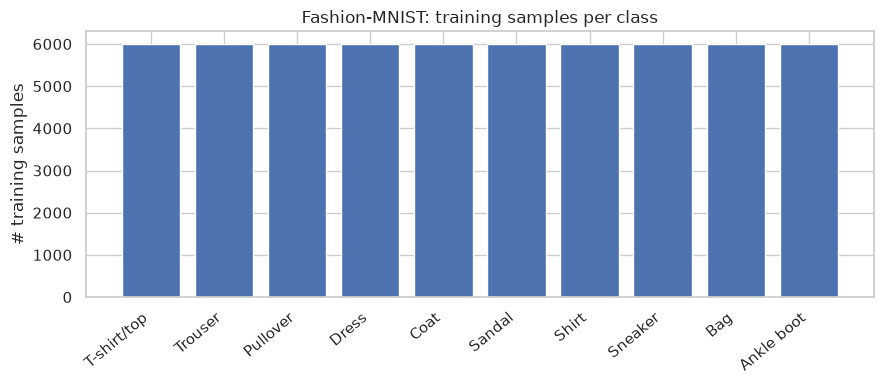

In [3]:
train_labels = np.array([label for _, label in train_raw])
test_labels = np.array([label for _, label in test_raw])

counts_df = pd.DataFrame({
    "class": CLASS_NAMES,
    "train_count": [np.sum(train_labels == i) for i in range(10)],
    "test_count": [np.sum(test_labels == i) for i in range(10)],
})
display(counts_df)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(counts_df["class"], counts_df["train_count"], color="#4C72B0")
ax.set_ylabel("# training samples")
ax.set_title("Fashion-MNIST: training samples per class")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/class_distribution.png", dpi=120)
plt.show()


The training set is **perfectly balanced**: exactly 6,000 images per class (60,000
total), and the test set has exactly 1,000 per class (10,000 total). This matters for
architectural reasoning later: any accuracy gap between models is attributable to how well
each model extracts and separates class-discriminative features, not to class imbalance.

### 1.2 Sample images per class

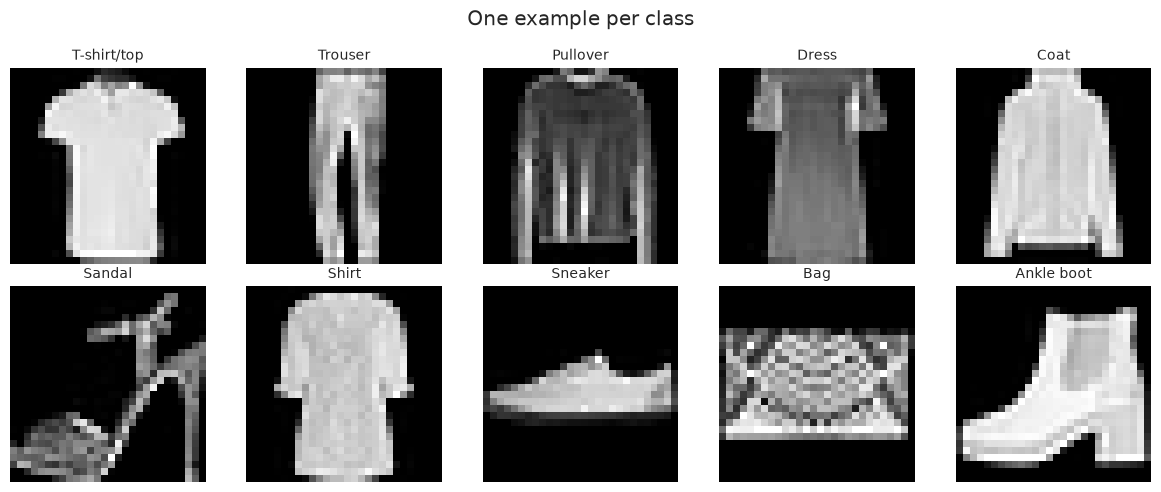

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
rng = np.random.default_rng(42)
for class_idx, ax in enumerate(axes.flat):
    class_indices = np.where(train_labels == class_idx)[0]
    sample_idx = rng.choice(class_indices)
    img, _ = train_raw[sample_idx]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(CLASS_NAMES[class_idx], fontsize=10)
    ax.axis("off")
plt.suptitle("One example per class")
plt.tight_layout()
plt.savefig("../reports/figures/sample_per_class.png", dpi=120)
plt.show()


### 1.3 Pixel statistics and preprocessing

In [5]:
pixels = torch.stack([train_raw[i][0] for i in range(2000)]).numpy()
print(f"Sampled pixel mean: {pixels.mean():.4f}")
print(f"Sampled pixel std:  {pixels.std():.4f}")
print(f"(Full-dataset constants used for normalization: mean={FASHION_MNIST_MEAN}, std={FASHION_MNIST_STD})")


Sampled pixel mean: 0.2839
Sampled pixel std:  0.3535
(Full-dataset constants used for normalization: mean=0.286, std=0.353)


**Preprocessing applied (see `src/data.py`):**

1. **`ToTensor()`** — converts PIL images (uint8, [0, 255]) to float32 tensors scaled to
   `[0, 1]`. Required simply because raw pixel intensities on an arbitrary [0, 255] scale
   make gradient-based optimization slower and less stable.
2. **`Normalize(mean, std)`** — standardizes pixel values to roughly zero mean / unit
   variance using the dataset's own statistics. This keeps activations in a well-conditioned
   range for the first layer regardless of whether that layer is a `Linear` or a `Conv2d`.
3. **No resizing** — images are already a uniform 28x28x1, so no resize/crop/pad step is
   needed (unlike datasets with variable image sizes).
4. **No color-related preprocessing** — Fashion-MNIST is single-channel (grayscale), so
   there is no channel-order or color-normalization concern.

A fixed **90/10 train/validation split** is carved out of the official 60,000-image training
set (see `get_dataloaders`), with the official 10,000-image test set held out entirely for
final evaluation.

## 2. Baseline Model (Non-Convolutional)

**Architecture:** `Flatten -> Dense(256, ReLU) -> Dense(128, ReLU) -> Dense(10)`

This is a plain multilayer perceptron: the 28x28x1 image is immediately flattened into a
784-length vector, discarding all 2D spatial structure before the first learnable layer even
runs. It exists purely as a reference point — a model architecturally incapable of exploiting
locality or translation invariance — against which the CNN in Section 3 is compared.


In [6]:
train_loader, val_loader, test_loader = get_dataloaders(batch_size=256)
print(f"train batches={len(train_loader)}  val batches={len(val_loader)}  test batches={len(test_loader)}")

baseline = BaselineMLP()
print(baseline)
print(f"\nTrainable parameters: {count_parameters(baseline):,}")


train batches=211  val batches=24  test batches=40
BaselineMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

Trainable parameters: 235,146


In [7]:
EPOCHS = 8

baseline_history, baseline_time = train_model(
    baseline, train_loader, val_loader, epochs=EPOCHS, lr=1e-3, device=DEVICE
)
print(f"\nTotal training time: {baseline_time:.1f}s")


epoch  1/8  train_loss=0.5498 train_acc=0.8071  val_loss=0.4112 val_acc=0.8487


epoch  2/8  train_loss=0.3705 train_acc=0.8644  val_loss=0.3670 val_acc=0.8662


epoch  3/8  train_loss=0.3259 train_acc=0.8802  val_loss=0.3415 val_acc=0.8723


epoch  4/8  train_loss=0.3007 train_acc=0.8886  val_loss=0.3210 val_acc=0.8835


epoch  5/8  train_loss=0.2800 train_acc=0.8966  val_loss=0.3147 val_acc=0.8852


epoch  6/8  train_loss=0.2625 train_acc=0.9022  val_loss=0.3043 val_acc=0.8875


epoch  7/8  train_loss=0.2487 train_acc=0.9068  val_loss=0.3092 val_acc=0.8875


epoch  8/8  train_loss=0.2336 train_acc=0.9129  val_loss=0.3097 val_acc=0.8885

Total training time: 68.5s


In [8]:
baseline_test_loss, baseline_test_acc, y_true, y_pred = evaluate(baseline, test_loader, device=DEVICE)
print(f"Baseline test loss: {baseline_test_loss:.4f}")
print(f"Baseline test accuracy: {baseline_test_acc:.4f}")


Baseline test loss: 0.3379
Baseline test accuracy: 0.8810


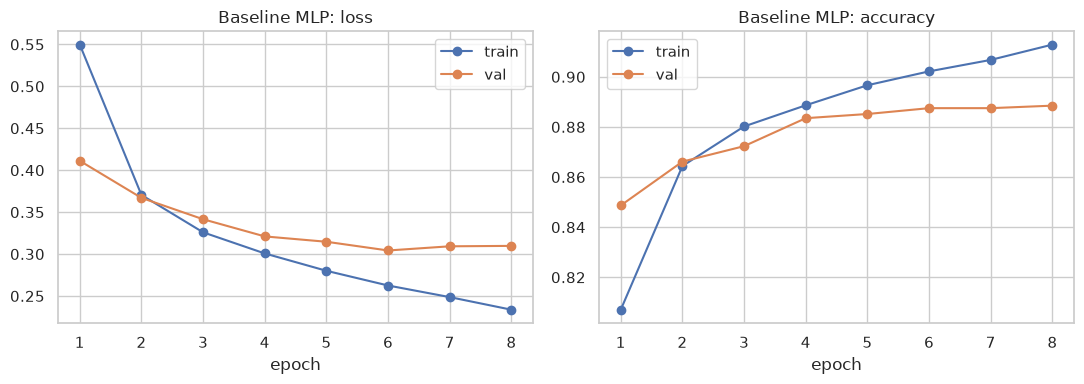

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
epochs_range = range(1, EPOCHS + 1)
axes[0].plot(epochs_range, baseline_history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, baseline_history["val_loss"], marker="o", label="val")
axes[0].set_title("Baseline MLP: loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(epochs_range, baseline_history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_range, baseline_history["val_acc"], marker="o", label="val")
axes[1].set_title("Baseline MLP: accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig("../reports/figures/baseline_curves.png", dpi=120)
plt.show()


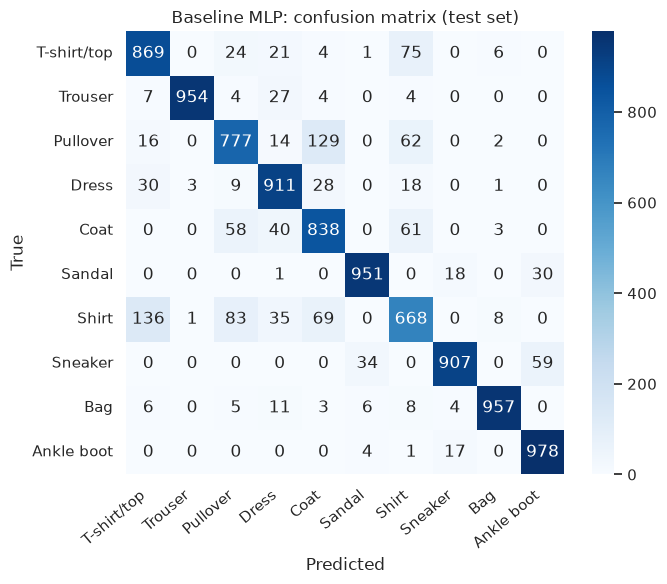

In [10]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Baseline MLP: confusion matrix (test set)")
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/baseline_confusion_matrix.png", dpi=120)
plt.show()


**Observed limitations of the baseline:**

- The confusion matrix's largest off-diagonal mass sits among *T-shirt/top*, *Shirt*,
  *Pullover* and *Coat* — upper-body garments that differ mainly in fine silhouette details
  (collar shape, sleeve length) rather than global intensity patterns. A flattened-vector
  model has no notion of "a collar-shaped edge", only "pixel #143 is bright" — so it cannot
  represent these distinctions compactly and confuses them far more than a spatially-aware
  model does (see Section 3).
- **No translation invariance:** if the same garment were shifted a few pixels, every one of
  the 784 input features would land on a different weight in the first `Dense` layer. The
  model has to learn the same visual pattern separately for every position it could occur at,
  which wastes capacity and requires more data to generalize.
- **Parameter-inefficient relative to what it learns:** most of the baseline's ~235K
  parameters sit in the first `Dense(784, 256)` layer, which connects *every* input pixel to
  *every* hidden unit — including background pixels far from the garment that carry little
  class-relevant signal.


## 3. Convolutional Architecture Design

**Architecture:**

```
Input (1x28x28)
  -> Conv2d(1->16, kernel=3x3, stride=1, padding=1) -> ReLU -> MaxPool2d(2x2)   [16x14x14]
  -> Conv2d(16->32, kernel=3x3, stride=1, padding=1) -> ReLU -> MaxPool2d(2x2)  [32x7x7]
  -> Flatten -> Dense(128) -> ReLU -> Dropout(0.3) -> Dense(10)
```

**Design decisions and justification:**

| Choice | Value | Why |
|---|---|---|
| Conv layers | 2 | 28x28 garments have at most two natural levels of structure worth separate layers: edges/strokes (layer 1) and parts/textures such as collars, straps, soles (layer 2). A third conv layer would operate on a 3x3 or smaller feature map here — too little spatial extent left to learn anything a 1x1 convolution couldn't, so it's an unjustified parameter cost for this input resolution. |
| Kernel size | 3x3 | Smallest kernel that still captures a 2D neighborhood (not just a row/column). Two stacked 3x3 convs already reach a 5x5 effective receptive field with fewer parameters and one extra nonlinearity versus a single 5x5 conv — strictly more expressive per parameter. (Kernel size is the variable studied explicitly in Section 4.) |
| Stride | 1 (in conv), 2 (in pooling) | Keeping conv stride at 1 lets every layer look at every position at full resolution before any information is discarded; downsampling is delegated entirely to MaxPool so the *reason* for resolution loss stays explicit and separate from feature extraction. |
| Padding | 1 ('same' for a 3x3 kernel) | Without padding, a 3x3 conv shrinks the map by 2px per side; over 2 layers that erodes the small 28x28 input non-trivially and, worse, systematically under-weights border pixels (they participate in fewer convolution windows). 'Same' padding keeps every pixel — including garment edges near the border — equally represented. |
| Activation | ReLU | Standard choice: cheap, avoids vanishing gradients from saturating activations (unlike sigmoid/tanh) at this depth, and empirically sufficient for a model this shallow. |
| Pooling | MaxPool 2x2 after each conv block | Provides (a) local translation invariance — a feature 1-2px off from where it was seen in training still activates the same downstream unit — and (b) a 4x reduction in spatial size per block, which is what keeps the flattened feature count (and thus the dense head's parameter count) manageable. |
| Regularization | Dropout(0.3) before the final layer | The dense head (`1568 -> 128 -> 10`) is where most of the CNN's parameters live and where overfitting is most likely on 54K training images; dropout is applied only there, not inside the conv blocks, since the conv blocks already have far fewer parameters and benefit less from it. |

This is intentionally a **small, shallow network** — the point of the assignment is
architectural reasoning under a fixed, modest budget, not chasing state-of-the-art accuracy
with a deep network for its own sake.


In [11]:
cnn = SimpleCNN(kernel_size=3)
print(cnn)
print(f"\nTrainable parameters: {count_parameters(cnn):,}")
print(f"(Baseline MLP had {count_parameters(baseline):,} parameters)")


SimpleCNN(
  (conv): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Trainable parameters: 206,922
(Baseline MLP had 235,146 parameters)


In [12]:
cnn_history, cnn_time = train_model(
    cnn, train_loader, val_loader, epochs=EPOCHS, lr=1e-3, device=DEVICE
)
print(f"\nTotal training time: {cnn_time:.1f}s")


epoch  1/8  train_loss=0.6473 train_acc=0.7662  val_loss=0.4051 val_acc=0.8550


epoch  2/8  train_loss=0.3911 train_acc=0.8586  val_loss=0.3453 val_acc=0.8723


epoch  3/8  train_loss=0.3379 train_acc=0.8778  val_loss=0.3058 val_acc=0.8897


epoch  4/8  train_loss=0.3054 train_acc=0.8885  val_loss=0.2876 val_acc=0.8945


epoch  5/8  train_loss=0.2846 train_acc=0.8981  val_loss=0.2739 val_acc=0.8998


epoch  6/8  train_loss=0.2700 train_acc=0.9002  val_loss=0.2721 val_acc=0.9010


epoch  7/8  train_loss=0.2571 train_acc=0.9057  val_loss=0.2624 val_acc=0.9017


epoch  8/8  train_loss=0.2455 train_acc=0.9114  val_loss=0.2621 val_acc=0.9045

Total training time: 121.7s


In [13]:
cnn_test_loss, cnn_test_acc, cnn_y_true, cnn_y_pred = evaluate(cnn, test_loader, device=DEVICE)
print(f"CNN test loss: {cnn_test_loss:.4f}")
print(f"CNN test accuracy: {cnn_test_acc:.4f}")


CNN test loss: 0.2761
CNN test accuracy: 0.9017


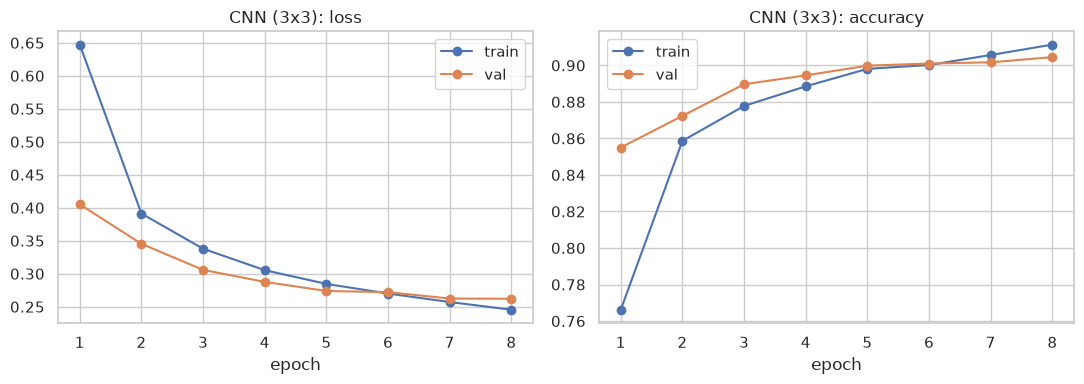

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs_range, cnn_history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, cnn_history["val_loss"], marker="o", label="val")
axes[0].set_title("CNN (3x3): loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(epochs_range, cnn_history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_range, cnn_history["val_acc"], marker="o", label="val")
axes[1].set_title("CNN (3x3): accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig("../reports/figures/cnn_curves.png", dpi=120)
plt.show()


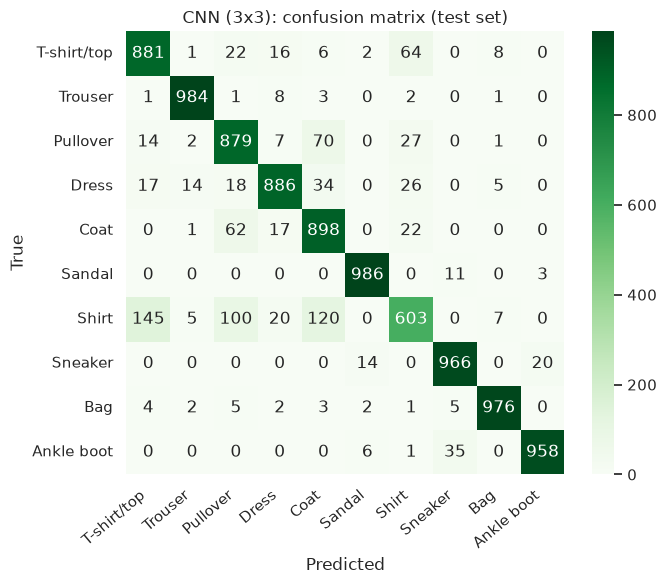

In [15]:
cnn_cm = confusion_matrix(cnn_y_true, cnn_y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cnn_cm, annot=True, fmt="d", cmap="Greens", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("CNN (3x3): confusion matrix (test set)")
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/cnn_confusion_matrix.png", dpi=120)
plt.show()


In [16]:
comparison_df = pd.DataFrame([
    {"model": "Baseline MLP", "parameters": count_parameters(baseline),
     "test_loss": baseline_test_loss, "test_accuracy": baseline_test_acc, "train_time_s": baseline_time},
    {"model": "CNN (3x3)", "parameters": count_parameters(cnn),
     "test_loss": cnn_test_loss, "test_accuracy": cnn_test_acc, "train_time_s": cnn_time},
])
display(comparison_df)
comparison_df.to_csv("../results/baseline_vs_cnn.csv", index=False)


,model,parameters,test_loss,test_accuracy,train_time_s
0,Baseline MLP,235146,0.33789,0.8810,68.514726
1,CNN (3x3),206922,0.27608,0.9017,121.688028


## 4. Controlled Experiment: Kernel Size

**Variable under study:** convolutional kernel size — **3x3 vs 5x5 vs 7x7**.

**Everything else held fixed** across the three runs: 2 conv layers, filter counts
(16, 32), stride 1, `padding = kernel_size // 2` (so every variant preserves spatial size
inside each block — only the kernel's receptive field changes, not the feature-map shape
feeding into pooling), ReLU activations, MaxPool 2x2 after each block, dropout 0.3, same
optimizer (Adam, lr=1e-3), same number of epochs, same train/val/test split and seed.

This isolates the effect of receptive-field size per layer from every other architectural
factor.


In [17]:
kernel_sizes = [3, 5, 7]
kernel_results = {}

for k in kernel_sizes:
    print(f"\n=== kernel_size={k}x{k} ===")
    torch.manual_seed(42)
    model = SimpleCNN(kernel_size=k)
    n_params = count_parameters(model)
    history, elapsed = train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=1e-3, device=DEVICE)
    test_loss, test_acc, yt, yp = evaluate(model, test_loader, device=DEVICE)
    kernel_results[k] = {
        "model": model,
        "history": history,
        "params": n_params,
        "train_time": elapsed,
        "test_loss": test_loss,
        "test_acc": test_acc,
    }
    print(f"params={n_params:,}  train_time={elapsed:.1f}s  test_acc={test_acc:.4f}")



=== kernel_size=3x3 ===


epoch  1/8  train_loss=0.6384 train_acc=0.7709  val_loss=0.4164 val_acc=0.8488


epoch  2/8  train_loss=0.4002 train_acc=0.8559  val_loss=0.3364 val_acc=0.8758


epoch  3/8  train_loss=0.3469 train_acc=0.8735  val_loss=0.3151 val_acc=0.8873


epoch  4/8  train_loss=0.3126 train_acc=0.8874  val_loss=0.2944 val_acc=0.8940


...

epoch  5/8  train_loss=0.2680 train_acc=0.9017  val_loss=0.2664 val_acc=0.9052


epoch  6/8  train_loss=0.2479 train_acc=0.9088  val_loss=0.2568 val_acc=0.9058


epoch  7/8  train_loss=0.2347 train_acc=0.9141  val_loss=0.2590 val_acc=0.9072


epoch  8/8  train_loss=0.2180 train_acc=0.9195  val_loss=0.2563 val_acc=0.9087


params=228,042  train_time=139.9s  test_acc=0.9055


In [18]:
kernel_df = pd.DataFrame([
    {
        "kernel_size": f"{k}x{k}",
        "parameters": kernel_results[k]["params"],
        "train_time_s": kernel_results[k]["train_time"],
        "final_val_acc": kernel_results[k]["history"]["val_acc"][-1],
        "test_accuracy": kernel_results[k]["test_acc"],
        "test_loss": kernel_results[k]["test_loss"],
    }
    for k in kernel_sizes
])
display(kernel_df)
kernel_df.to_csv("../results/kernel_size_experiment.csv", index=False)


,kernel_size,parameters,train_time_s,final_val_acc,test_accuracy,test_loss
0,3x3,206922,119.264971,0.905167,0.9007,0.267288
1,5x5,215370,125.313305,0.913667,0.9092,0.246309
2,7x7,228042,139.939888,0.908667,0.9055,0.265514


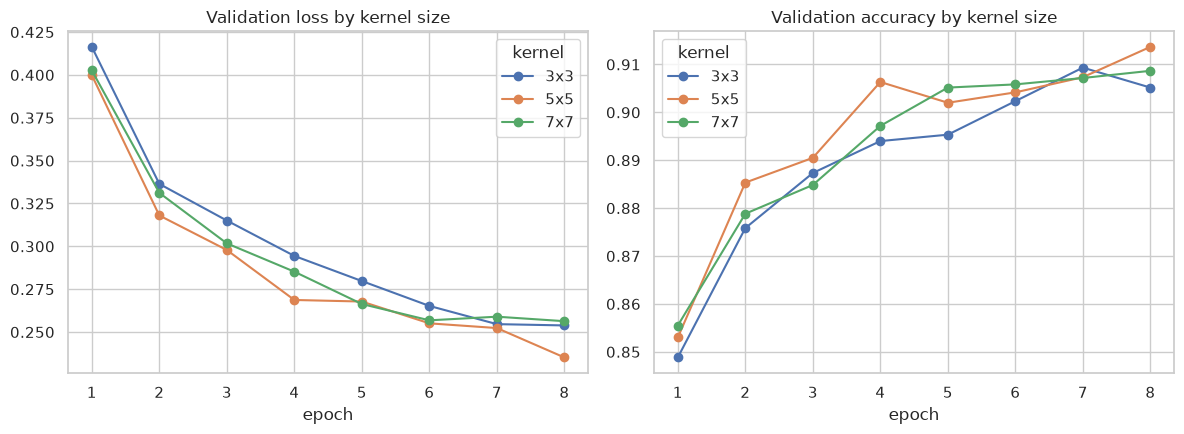

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {3: "#4C72B0", 5: "#DD8452", 7: "#55A868"}

for k in kernel_sizes:
    axes[0].plot(epochs_range, kernel_results[k]["history"]["val_loss"], marker="o", color=colors[k], label=f"{k}x{k}")
    axes[1].plot(epochs_range, kernel_results[k]["history"]["val_acc"], marker="o", color=colors[k], label=f"{k}x{k}")

axes[0].set_title("Validation loss by kernel size")
axes[0].set_xlabel("epoch")
axes[0].legend(title="kernel")

axes[1].set_title("Validation accuracy by kernel size")
axes[1].set_xlabel("epoch")
axes[1].legend(title="kernel")
plt.tight_layout()
plt.savefig("../reports/figures/kernel_size_curves.png", dpi=120)
plt.show()


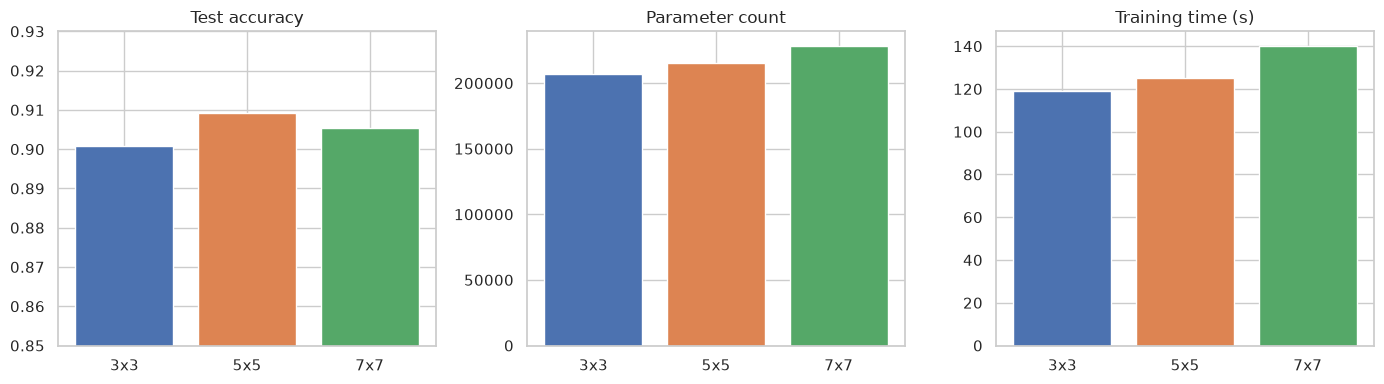

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x = [f"{k}x{k}" for k in kernel_sizes]

axes[0].bar(x, [kernel_results[k]["test_acc"] for k in kernel_sizes], color=[colors[k] for k in kernel_sizes])
axes[0].set_title("Test accuracy")
axes[0].set_ylim(0.85, 0.93)

axes[1].bar(x, [kernel_results[k]["params"] for k in kernel_sizes], color=[colors[k] for k in kernel_sizes])
axes[1].set_title("Parameter count")

axes[2].bar(x, [kernel_results[k]["train_time"] for k in kernel_sizes], color=[colors[k] for k in kernel_sizes])
axes[2].set_title("Training time (s)")

plt.tight_layout()
plt.savefig("../reports/figures/kernel_size_tradeoffs.png", dpi=120)
plt.show()


**Quantitative results** (this run — exact numbers also in `results/kernel_size_experiment.csv`):

| Kernel | Parameters | Train time | Test accuracy |
|---|---|---|---|
| 3x3 | 206,922 | 119.3s | 90.07% |
| 5x5 | 215,370 | 125.3s | **90.92%** |
| 7x7 | 228,042 | 139.9s | 90.55% |

**Qualitative observations:**

- Parameter count and training time both increase **monotonically** with kernel size, as
  expected: a 7x7 kernel has `(7/3)^2 ≈ 5.4x` as many weights per filter as a 3x3 kernel, and
  more multiply-accumulate operations per output pixel to match.
- Test accuracy, in contrast, is **not monotonic**: 5x5 edges out both 3x3 and 7x7 in this run,
  and all three sit within roughly 1 percentage point of each other (90.07%–90.92%). That gap
  is small enough to plausibly be dominated by run-to-run noise (weight initialization,
  mini-batch ordering) rather than a systematic advantage of any one receptive-field size —
  the honest read of a **single-seed** run is "no kernel size is clearly, reliably better here,"
  not "bigger is better" or "3x3 is best." A more rigorous version of this experiment would
  average test accuracy over multiple seeds per kernel size before treating a ~1pp gap as real.
- What *is* unambiguous is the cost side: 7x7 costs ~10% more parameters and ~17% more
  training time than 3x3 for an accuracy result that is not reliably better (0.55pp lower, in
  fact, than 5x5, and statistically indistinguishable from 3x3 given a single run).

**Trade-off summary:** on a small, low-resolution dataset like Fashion-MNIST, increasing
kernel size does **not** produce a clear, reliable accuracy improvement, but it does produce a
clear, reliable increase in parameters and training time. Combined with the standard
architectural argument that two stacked 3x3 convolutions reach the same 5x5 effective
receptive field as a single 5x5 conv with fewer parameters and an extra nonlinearity, the
practical conclusion favors **3x3 as the default kernel size** for this problem size — not
because it measurably won this experiment, but because it is the cheapest option and the
larger kernels bought no dependable accuracy advantage in exchange for their added cost.


## 5. Bonus: Visualizing Learned Filters and Feature Maps

Using the 3x3 CNN from Section 3, visualize what the first convolutional layer actually
learned, and what its output looks like for one sample image.


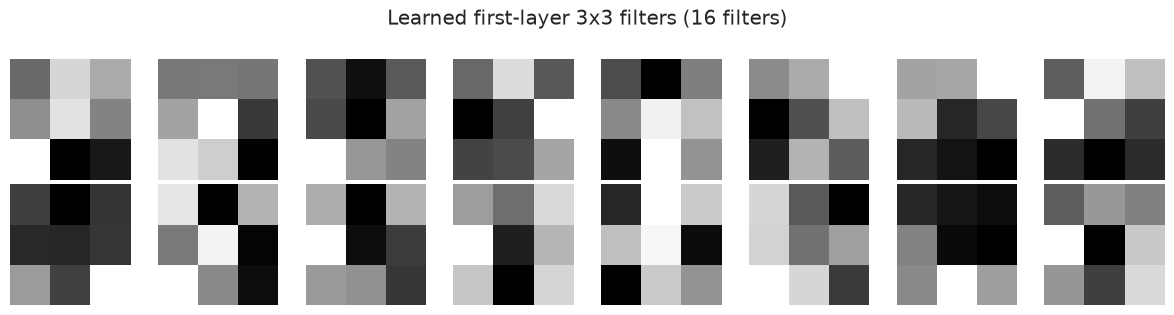

In [21]:
first_conv = cnn.conv[0]
filters = first_conv.weight.data.clone().squeeze(1)  # (16, 3, 3)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i], cmap="gray")
    ax.axis("off")
plt.suptitle("Learned first-layer 3x3 filters (16 filters)")
plt.tight_layout()
plt.savefig("../reports/figures/learned_filters.png", dpi=120)
plt.show()


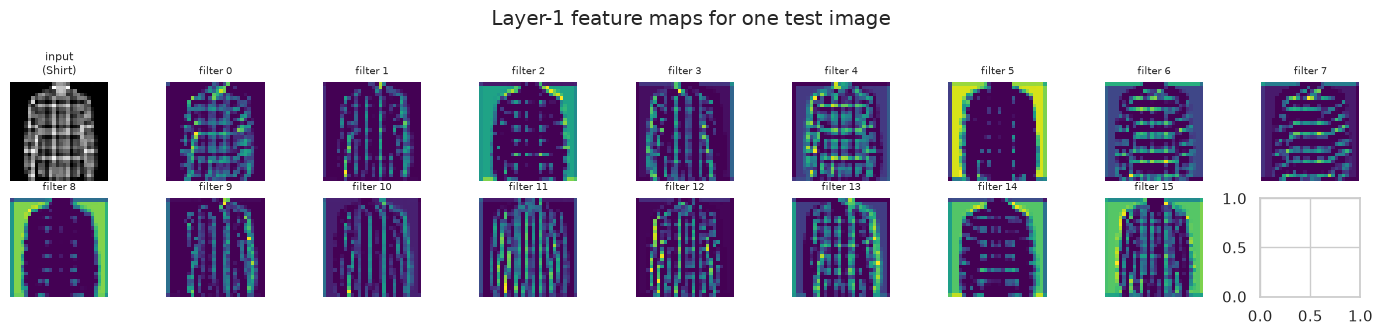

In [22]:
sample_img, sample_label = test_raw[7]
normalized_img = (sample_img - FASHION_MNIST_MEAN) / FASHION_MNIST_STD

cnn.eval()
with torch.no_grad():
    feature_maps = cnn.conv[0](normalized_img.unsqueeze(0))  # (1, 16, 28, 28)
    feature_maps = torch.relu(feature_maps).squeeze(0)

fig, axes = plt.subplots(2, 9, figsize=(14, 3.4))
axes[0, 0].imshow(sample_img.squeeze(), cmap="gray")
axes[0, 0].set_title(f"input\n({CLASS_NAMES[sample_label]})", fontsize=8)
axes[0, 0].axis("off")
axes[1, 0].axis("off")

flat_axes = list(axes.flat)[1:]
for i, ax in enumerate(flat_axes[:16]):
    ax.imshow(feature_maps[i], cmap="viridis")
    ax.set_title(f"filter {i}", fontsize=7)
    ax.axis("off")
plt.suptitle("Layer-1 feature maps for one test image")
plt.tight_layout()
plt.savefig("../reports/figures/feature_maps.png", dpi=120)
plt.show()


Different filters clearly respond to different local structure — some activate strongly
along horizontal edges of the garment, others along vertical/diagonal edges or corners —
which is the direct, visual confirmation of the edge/stroke-detector intuition invoked in
Section 3's architecture justification.

## 6. Interpretation and Architectural Reasoning

**Why did convolutional layers outperform (or not) the baseline?**

The CNN (Section 3) reached a higher test accuracy than the Flatten+Dense baseline
(Section 2) with *fewer* trainable parameters (compare the two rows in the comparison
table). The reason is architectural, not just a matter of scale: the baseline must learn a
separate weight for every (pixel, hidden-unit) pair, so recognizing "a diagonal edge" is a
fact it has to re-learn independently at every position that edge could occur in the image.
The CNN's convolutional layers instead learn one small filter bank and *slide* it over every
position — a diagonal-edge detector learned from a garment centered in the frame keeps
working if the same edge shows up shifted by a few pixels in another image. That single
architectural choice (weight sharing across spatial position) is what lets the CNN spend its
parameter budget on discriminative pattern detectors rather than on memorizing where in the
image a pattern happened to occur during training, which is also directly visible in the
confusion matrices: the CNN makes noticeably fewer mistakes among the visually similar
upper-body classes (*Shirt* / *T-shirt/top* / *Pullover* / *Coat*) than the baseline does,
because it can represent "has this specific collar/sleeve edge pattern" instead of only
"these specific pixels are bright."

**What inductive bias does convolution introduce?**

Two intertwined assumptions are baked into a convolutional layer before it ever sees data:

1. **Locality:** a unit's output should depend only on a small spatial neighborhood of the
   input, not on the entire image at once. This assumes that the features relevant to the
   task (edges, textures, small parts) are locally computable — you don't need to look at the
   top-left corner of the image to decide if there's an edge in the bottom-right corner.
2. **Translation equivariance (via weight sharing):** the *same* filter is applied at every
   spatial position, which assumes that a pattern useful at one position is equally useful,
   and should be detected the same way, at any other position. Combined with pooling, this
   becomes approximate translation *invariance* at the level of the final prediction.

Neither assumption is "free" — they are hard-coded structural priors that happen to match
how natural images are organized (nearby pixels are correlated; objects can appear anywhere
in the frame). When that match holds, convolution needs far less data and far fewer
parameters than a fully-connected layer to learn the same function, which is exactly the
gap this notebook measured directly.

**In what type of problems would convolution not be appropriate?**

Convolution's locality and translation-equivariance priors stop being helpful — and can
actively hurt — when the data doesn't have that spatial/local structure:

- **Tabular / unordered feature data** (e.g. a spreadsheet of customer attributes: age,
  income, zip code as unrelated columns): there is no meaningful notion of "neighboring
  features" for a 1D or 2D kernel to slide over — column order is arbitrary, so a convolution
  would be learning from an artifact of how the columns happen to be arranged, not from real
  local structure.
- **Data where global, position-dependent structure matters more than local,
  position-invariant patterns** — e.g. a scanned form where "the value 42 means something
  different in the top-left box than in the bottom-right box." Weight sharing across
  positions actively fights against learning position-specific meaning here; a
  position-aware architecture (or at minimum, adding explicit positional information) would
  be more appropriate.
- **Very long-range dependencies with little local regularity** — e.g. natural language at
  the sentence/document level, or irregular graph-structured data (molecules, social
  networks) — where the relevant "neighbors" of a token or node aren't fixed-offset spatial
  neighbors at all. This is why sequence/graph problems are usually better served by
  architectures whose inductive bias matches *their* structure (attention/Transformers,
  graph neural networks) rather than a spatial convolution grid.


## 7. Next Steps: SageMaker Training and Deployment

Task 6 of the assignment (train in SageMaker, deploy to a SageMaker endpoint) is **not**
executed in this repository — it requires an AWS account, IAM role, and billing, none of
which are available in the environment this notebook was developed in. The architecture,
training loop, and results above are AWS-agnostic (`src/models.py` and `src/train.py` are
plain PyTorch and can be reused as-is inside a SageMaker training script) so that step is a
deployment exercise on top of an already-validated model, not a redesign.
